In [1]:
import sys
from pathlib import Path

project_root = Path().resolve().parent
sys.path.append(str(project_root))

from src.incertidumbres import (
    graficar_imagen,
    crear_dataframe_incertidumbre,
    plot_incertidumbres,
    plot_combinado
)
from src.model_trainer import ModelTrainer
from src.image_preprocessor import ImagePreprocessor
import pickle
import pandas as pd
import tensorflow as tf

/Users/camcortes/Documents/birds-sounds/.venv-birds-song/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
model_name = "ResNet152V2" #"MobileNetV3Large" #"EfficientNetV2L" #"ResNet152V2" #"EfficientNetB7"

model_trainer = ModelTrainer(
    model_name=model_name,
    img_shape=(128, 256, 1),
    n_classes=667,
    dropout_rate=0.2,
    label_smoothing=0.1,
    fine_tune_layers=200
)

model = model_trainer.create_model()
model.summary()
model.load_weights(f"../models/weights_{model_name}.weights.h5")
tf.keras.backend.clear_session()

Model: "ResNet152V2_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 256, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 128, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ preprocess_input (Lambda)       │ (None, 128, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet152v2 (Functional)        │ (None, 2048)           │    58,331,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ top_dropout (Dropout)           │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ logits (Dense)                  │ (None, 667)            │     1,366,683 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 59,698,331 (227.73 MB)

 Trainable params: 32,846,491 (125.30 MB)

 Non-trainable params: 26,851,840 (102.43 MB)

/Users/camcortes/Documents/birds-sounds/.venv-birds-song/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 368 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [3]:
with open(f'../models/label_encoder_{model_name}.pkl', 'rb') as f:
    label_encoder = pickle.load(f)

In [4]:
preprocessor = ImagePreprocessor(label_encoder=label_encoder)
data = preprocessor.load_data_from_directory("../src/data/images_test/images_spectograms")
data.head()

,label,image_path
0,Acropternis orthonyx,../src/data/images_test/images_spectograms/Acropternis orthonyx/121142_13.jpeg
1,Acropternis orthonyx,../src/data/images_test/images_spectograms/Acropternis orthonyx/511703_5.jpeg
2,Acropternis orthonyx,../src/data/images_test/images_spectograms/Acropternis orthonyx/461011_0.jpeg
3,Acropternis orthonyx,../src/data/images_test/images_spectograms/Acropternis orthonyx/621780_9.jpeg
4,Acropternis orthonyx,../src/data/images_test/images_spectograms/Acropternis orthonyx/428484_0.jpeg


In [5]:
sp_metrics = pd.read_csv("../models/metrics_resnet.csv")

In [6]:
sp = data[data["label"] == "Lathrotriccus euleri"]
sp.sample(6)

,label,image_path
14713,Lathrotriccus euleri,../src/data/images_test/images_spectograms/Lathrotriccus euleri/427525_5.jpeg
14681,Lathrotriccus euleri,../src/data/images_test/images_spectograms/Lathrotriccus euleri/102718_1.jpeg
14697,Lathrotriccus euleri,../src/data/images_test/images_spectograms/Lathrotriccus euleri/72564_9.jpeg
14663,Lathrotriccus euleri,../src/data/images_test/images_spectograms/Lathrotriccus euleri/586950_4.jpeg
14670,Lathrotriccus euleri,../src/data/images_test/images_spectograms/Lathrotriccus euleri/427525_13.jpeg
14692,Lathrotriccus euleri,../src/data/images_test/images_spectograms/Lathrotriccus euleri/272813_0.jpeg


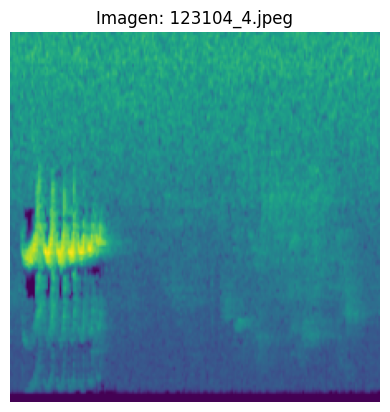

In [7]:
graficar_imagen(sp['image_path'].iloc[32])

# **Volatinia jacarina**

In [8]:
sp = data[data["label"] == "Volatinia jacarina"]
muestra = sp[sp['image_path'].str.contains('146774_0.jpeg')]
muestra

,label,image_path
31431,Volatinia jacarina,../src/data/images_test/images_spectograms/Volatinia jacarina/146774_0.jpeg


In [9]:
df_final, resultados = crear_dataframe_incertidumbre(data, muestra, model, preprocessor)
df_final.head()

Especies procesadas:   0%|          | 0/1 [00:00<?, ?it/s]


Especie 1 de 1, (Volatinia jacarina)


2025-08-24 17:34:42.983241: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
Especies procesadas: 100%|██████████| 1/1 [00:08<00:00,  8.61s/it]


,especie,clase_real,clase_predicha,prediccion_mc,confianza_mc,true_positive,true_positivo_mc,entropia
0,Volatinia jacarina,651,651,651,0.02,1,1,6.44
1,Volatinia jacarina,651,651,114,0.01,1,0,6.44
2,Volatinia jacarina,651,651,651,0.01,1,1,6.44
3,Volatinia jacarina,651,651,651,0.01,1,1,6.44
4,Volatinia jacarina,651,651,651,0.01,1,1,6.44


In [10]:
Volatinia_jacarina = df_final['prediccion_mc'].\
    value_counts(normalize=True).reset_index().\
    sort_values(by='proportion', ascending=False).head(10)

In [11]:
Volatinia_jacarina

,prediccion_mc,proportion
0,651,0.85
1,114,0.05
2,298,0.05
3,641,0.05


/Users/camcortes/Documents/birds-sounds/src/incertidumbres.py:222: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


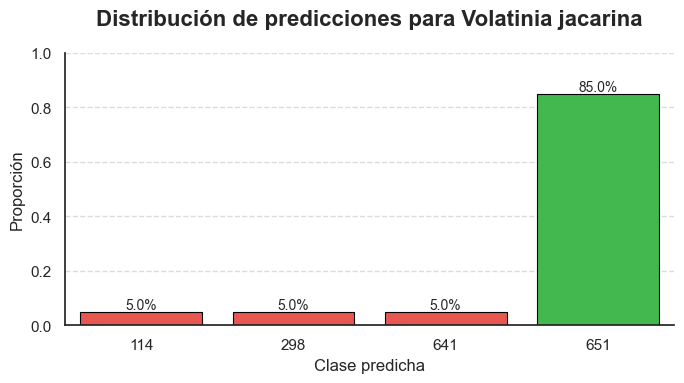

In [12]:
plot_incertidumbres(Volatinia_jacarina, 651, "Volatinia jacarina")

/Users/camcortes/Documents/birds-sounds/src/incertidumbres.py:378: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


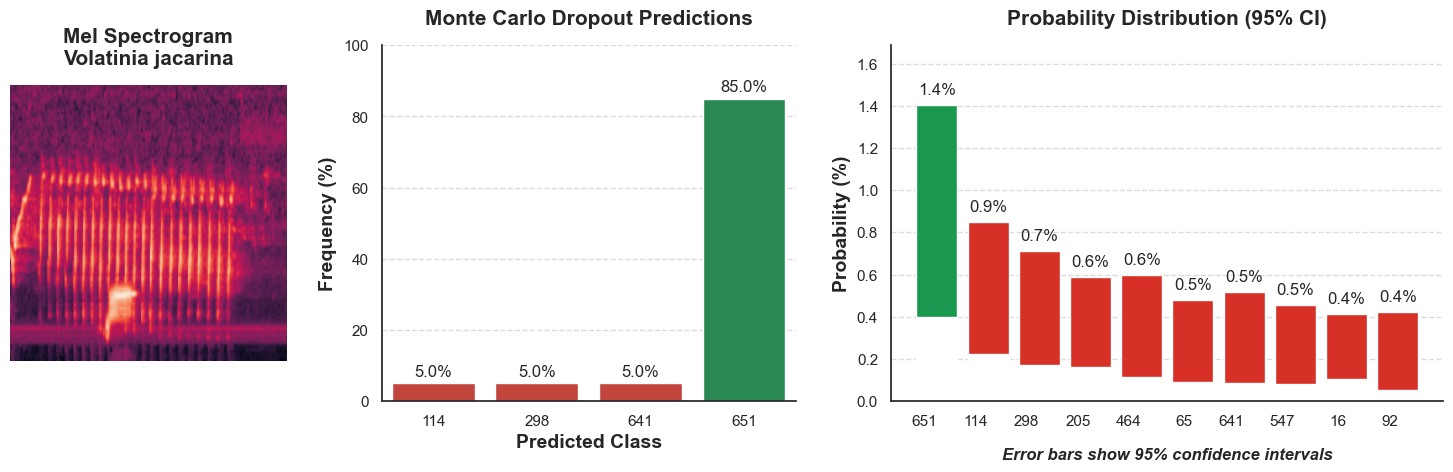

In [13]:
plot_combinado(
    ruta_imagen=sp['image_path'].iloc[1],
    especie_df=Volatinia_jacarina,
    label=651,
    titulo_especie="Volatinia jacarina",
    predicted_probabilities=resultados["Volatinia jacarina"]["predicted_probabilities"],
    etiqueta_real=resultados["Volatinia jacarina"]["clase_real"][0]
)

In [14]:
labels_frecuencia = [17, 65, 97, 114, 205, 298, 464, 554, 641, 651]

print("Especies con mayor probabilidad:\n")
for idx, label in enumerate(labels_frecuencia):
    print(f"{idx+1} - {label}: {label_encoder.inverse_transform([label])[0]}")

Especies con mayor probabilidad:

1 - 17: Arremon aurantiirostris
2 - 65: Cantorchilus leucotis
3 - 97: Chlorospingus canigularis
4 - 114: Coereba flaveola
5 - 205: Euphonia chrysopasta
6 - 298: Lanio fulvus
7 - 464: Pseudopipra pipra
8 - 554: Stelgidopteryx ruficollis
9 - 641: Vireo chivi
10 - 651: Volatinia jacarina


# **Legatus leucophaius**

In [15]:
sp = data[data["label"] == "Legatus leucophaius"]
muestra = sp[sp['image_path'].str.contains('275478_4.jpeg')]
muestra

,label,image_path
14744,Legatus leucophaius,../src/data/images_test/images_spectograms/Legatus leucophaius/275478_4.jpeg


In [16]:
df_final, resultados = crear_dataframe_incertidumbre(data, muestra, model, preprocessor)
df_final.head()

Especies procesadas:   0%|          | 0/1 [00:00<?, ?it/s]


Especie 1 de 1, (Legatus leucophaius)


2025-08-24 17:34:51.808438: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
Especies procesadas: 100%|██████████| 1/1 [00:08<00:00,  8.51s/it]


,especie,clase_real,clase_predicha,prediccion_mc,confianza_mc,true_positive,true_positivo_mc,entropia
0,Legatus leucophaius,301,301,344,0.01,1,0,6.46
1,Legatus leucophaius,301,301,301,0.01,1,1,6.46
2,Legatus leucophaius,301,301,301,0.01,1,1,6.46
3,Legatus leucophaius,301,301,344,0.01,1,0,6.46
4,Legatus leucophaius,301,301,92,0.00,1,0,6.46


In [17]:
Legatus_leucophaius = df_final['prediccion_mc'].\
    value_counts(normalize=True).reset_index().\
    sort_values(by='proportion', ascending=False).head(10)

In [18]:
Legatus_leucophaius

,prediccion_mc,proportion
0,301,0.55
1,344,0.10
2,92,0.05
3,99,0.05
4,261,0.05
5,63,0.05
6,128,0.05
7,536,0.05
8,213,0.05


/Users/camcortes/Documents/birds-sounds/src/incertidumbres.py:222: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


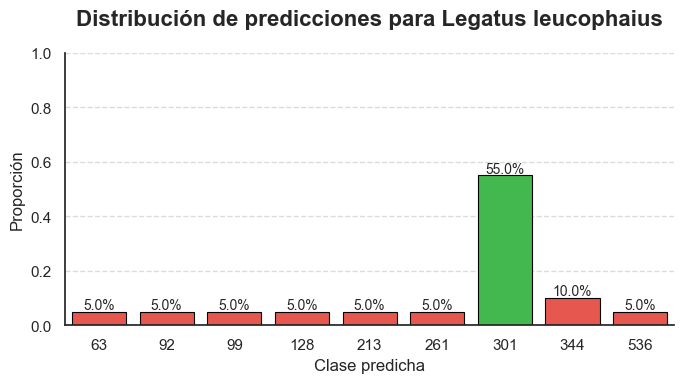

In [19]:
plot_incertidumbres(Legatus_leucophaius, 301, "Legatus leucophaius")

/Users/camcortes/Documents/birds-sounds/src/incertidumbres.py:378: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


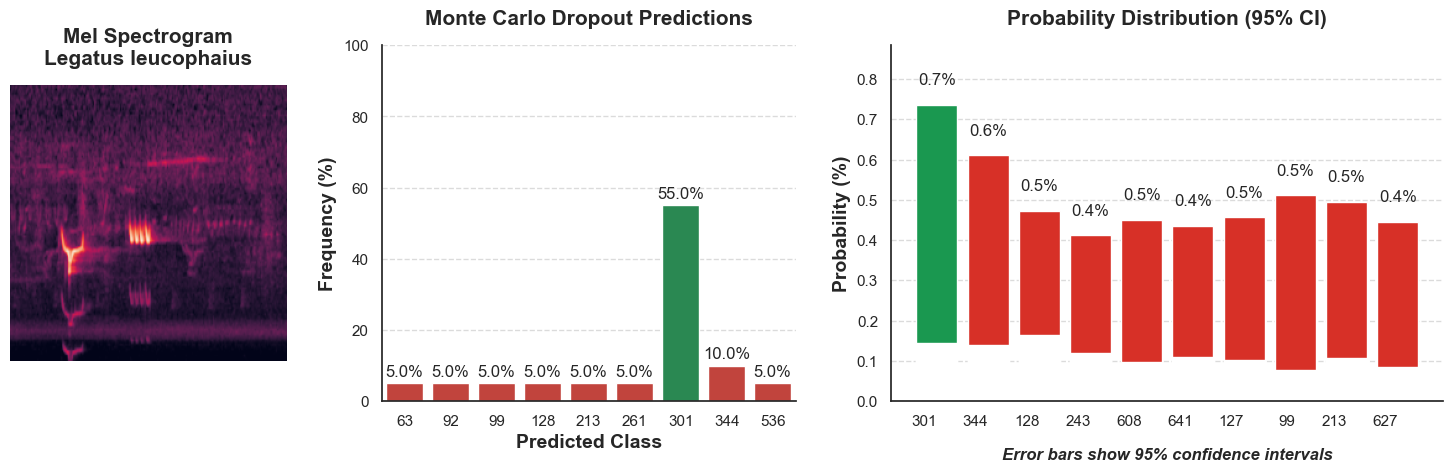

In [20]:
plot_combinado(
    ruta_imagen=sp['image_path'].iloc[1],
    especie_df=Legatus_leucophaius,
    label=301,
    titulo_especie="Legatus leucophaius",
    predicted_probabilities=resultados["Legatus leucophaius"]["predicted_probabilities"],
    etiqueta_real=resultados["Legatus leucophaius"]["clase_real"][0]
)

In [21]:
labels_frecuencia = [127, 128, 204, 214, 243, 301, 344, 608, 641, 654]

print("Especies con mayor probabilidad:\n")
for idx, label in enumerate(labels_frecuencia):
    print(f"{idx+1} - {label}: {label_encoder.inverse_transform([label])[0]}")

Especies con mayor probabilidad:

1 - 127: Contopus sordidulus
2 - 128: Contopus virens
3 - 204: Euphonia chlorotica
4 - 214: Euphonia xanthogaster
5 - 243: Grallaricula flavirostris
6 - 301: Legatus leucophaius
7 - 344: Myadestes ralloides
8 - 608: Thraupis episcopus
9 - 641: Vireo chivi
10 - 654: Xenops rutilans


# **Hylophilus thoracicus**

In [22]:
sp = data[data["label"] == "Hylophilus thoracicus"]
muestra = sp[sp['image_path'].str.contains('272368_8.jpeg')]
muestra

,label,image_path
13483,Hylophilus thoracicus,../src/data/images_test/images_spectograms/Hylophilus thoracicus/272368_8.jpeg


In [23]:
df_final, resultados = crear_dataframe_incertidumbre(data, muestra, model, preprocessor)
df_final.head()

Especies procesadas:   0%|          | 0/1 [00:00<?, ?it/s]


Especie 1 de 1, (Hylophilus thoracicus)


Especies procesadas: 100%|██████████| 1/1 [00:08<00:00,  8.54s/it]


,especie,clase_real,clase_predicha,prediccion_mc,confianza_mc,true_positive,true_positivo_mc,entropia
0,Hylophilus thoracicus,274,274,476,0.01,1,0,6.46
1,Hylophilus thoracicus,274,274,274,0.01,1,1,6.46
2,Hylophilus thoracicus,274,274,274,0.00,1,1,6.46
3,Hylophilus thoracicus,274,274,274,0.01,1,1,6.46
4,Hylophilus thoracicus,274,274,186,0.00,1,0,6.46


In [24]:
Hylophilus_thoracicus = df_final['prediccion_mc'].\
    value_counts(normalize=True).reset_index().\
    sort_values(by='proportion', ascending=False).head(10)

In [25]:
Hylophilus_thoracicus

,prediccion_mc,proportion
0,274,0.50
1,301,0.15
2,476,0.05
3,186,0.05
4,52,0.05
5,410,0.05
6,510,0.05
7,542,0.05
8,655,0.05


/Users/camcortes/Documents/birds-sounds/src/incertidumbres.py:222: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


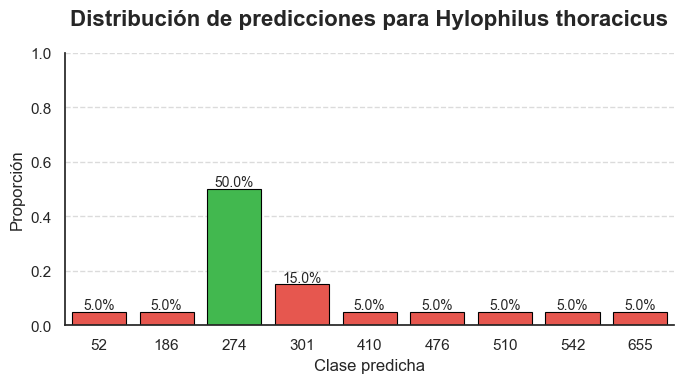

In [26]:
plot_incertidumbres(Hylophilus_thoracicus, 274, "Hylophilus thoracicus")

/Users/camcortes/Documents/birds-sounds/src/incertidumbres.py:378: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


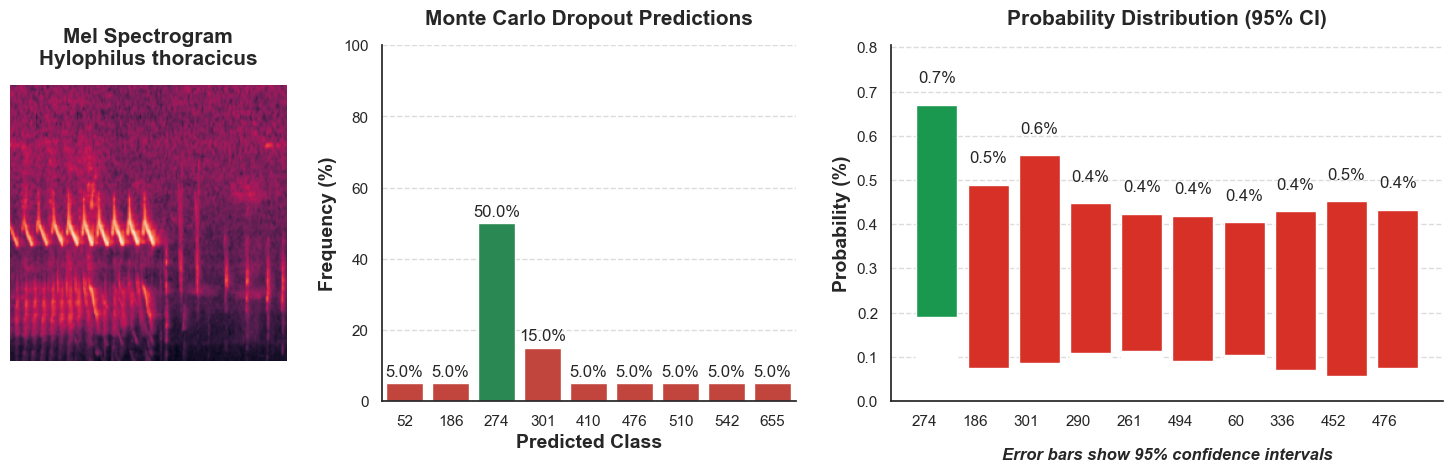

In [27]:
plot_combinado(
    ruta_imagen=sp['image_path'].iloc[0],
    especie_df=Hylophilus_thoracicus,
    label=274,
    titulo_especie="Hylophilus thoracicus",
    predicted_probabilities=resultados["Hylophilus thoracicus"]["predicted_probabilities"],
    etiqueta_real=resultados["Hylophilus thoracicus"]["clase_real"][0]
)

In [28]:
labels_frecuencia = [60, 186, 261, 274, 290, 301, 336, 452, 476, 494]

print("Especies con mayor probabilidad:\n")
for idx, label in enumerate(labels_frecuencia):
    print(f"{idx+1} - {label}: {label_encoder.inverse_transform([label])[0]}")

Especies con mayor probabilidad:

1 - 60: Campylorhamphus trochilirostris
2 - 186: Elaenia flavogaster
3 - 261: Henicorhina leucosticta
4 - 274: Hylophilus thoracicus
5 - 290: Inezia caudata
6 - 301: Legatus leucophaius
7 - 336: Microrhopias quixensis
8 - 452: Polioptila plumbea
9 - 476: Ramphastos tucanus
10 - 494: Saltator maximus


# **Mimus gilvus**

In [29]:
sp = data[data["label"] == "Mimus gilvus"]
muestra = sp[sp['image_path'].str.contains('40536_5.jpeg')]
muestra

,label,image_path
16615,Mimus gilvus,../src/data/images_test/images_spectograms/Mimus gilvus/40536_5.jpeg


In [30]:
df_final, resultados = crear_dataframe_incertidumbre(data, muestra, model, preprocessor)
df_final.head()

Especies procesadas:   0%|          | 0/1 [00:00<?, ?it/s]


Especie 1 de 1, (Mimus gilvus)


2025-08-24 17:35:09.661080: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
Especies procesadas: 100%|██████████| 1/1 [00:08<00:00,  8.63s/it]


,especie,clase_real,clase_predicha,prediccion_mc,confianza_mc,true_positive,true_positivo_mc,entropia
0,Mimus gilvus,338,338,513,0.00,1,0,6.45
1,Mimus gilvus,338,338,494,0.00,1,0,6.45
2,Mimus gilvus,338,338,284,0.00,1,0,6.45
3,Mimus gilvus,338,338,495,0.00,1,0,6.45
4,Mimus gilvus,338,338,636,0.00,1,0,6.45


In [31]:
Mimus_gilvus = df_final['prediccion_mc'].\
    value_counts(normalize=True).reset_index().\
    sort_values(by='proportion', ascending=False).head(10)

In [32]:
Mimus_gilvus

,prediccion_mc,proportion
0,338,0.20
1,636,0.15
2,494,0.10
3,495,0.10
4,621,0.10
5,513,0.05
6,284,0.05
7,66,0.05
8,405,0.05
9,640,0.05


/Users/camcortes/Documents/birds-sounds/src/incertidumbres.py:222: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


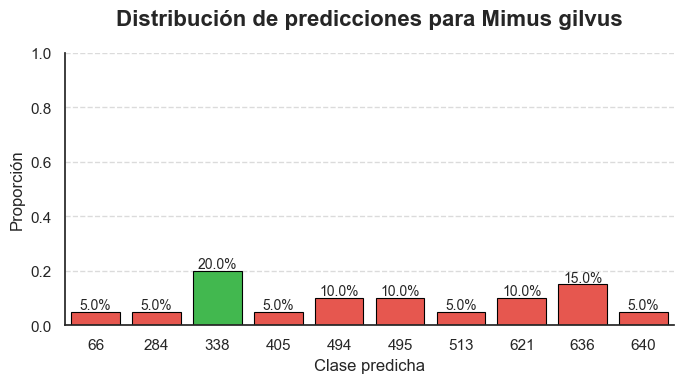

In [33]:
plot_incertidumbres(Mimus_gilvus, 338, "Mimus gilvus")

/Users/camcortes/Documents/birds-sounds/src/incertidumbres.py:378: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


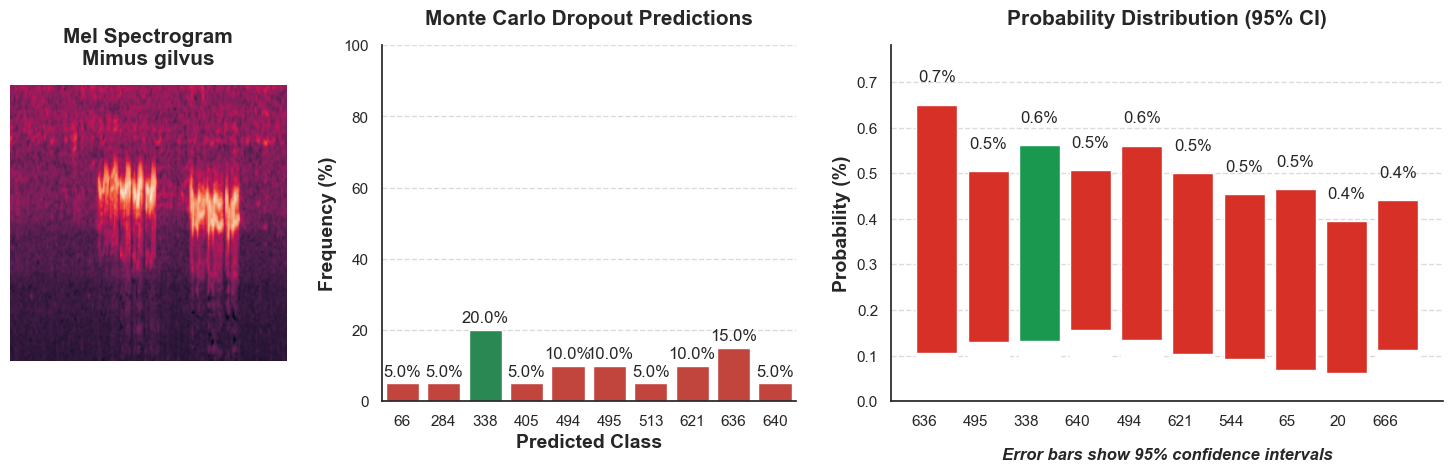

In [34]:
plot_combinado(
    ruta_imagen=sp['image_path'].iloc[20],
    especie_df=Mimus_gilvus,
    label=338,
    titulo_especie="Mimus gilvus",
    predicted_probabilities=resultados["Mimus gilvus"]["predicted_probabilities"],
    etiqueta_real=resultados["Mimus gilvus"]["clase_real"][0]
)

## Tareas
* Normalizar los labels para mejorar visualizacion 

In [35]:
labels_frecuencia = [65, 316, 338, 494, 495, 544, 621, 636, 640, 666]

print("Especies con mayor probabilidad:\n")
for idx, label in enumerate(labels_frecuencia):
    print(f"{idx+1} - {label}: {label_encoder.inverse_transform([label])[0]}")

Especies con mayor probabilidad:

1 - 65: Cantorchilus leucotis
2 - 316: Lophotriccus pileatus
3 - 338: Mimus gilvus
4 - 494: Saltator maximus
5 - 495: Saltator striatipectus
6 - 544: Sporophila castaneiventris
7 - 621: Todirostrum cinereum
8 - 636: Tyrannus melancholicus
9 - 640: Vireo altiloquus
10 - 666: Zonotrichia leucophrys


# **Lathrotriccus euleri**

In [36]:
sp = data[data["label"] == "Lathrotriccus euleri"]
muestra = sp[sp['image_path'].str.contains('123104_4.jpeg')]
muestra

,label,image_path
14676,Lathrotriccus euleri,../src/data/images_test/images_spectograms/Lathrotriccus euleri/123104_4.jpeg


In [37]:
df_final, resultados = crear_dataframe_incertidumbre(data, muestra, model, preprocessor)
df_final.head()

Especies procesadas:   0%|          | 0/1 [00:00<?, ?it/s]


Especie 1 de 1, (Lathrotriccus euleri)


Especies procesadas: 100%|██████████| 1/1 [00:08<00:00,  8.77s/it]


,especie,clase_real,clase_predicha,prediccion_mc,confianza_mc,true_positive,true_positivo_mc,entropia
0,Lathrotriccus euleri,300,277,370,0.01,0,0,6.46
1,Lathrotriccus euleri,300,277,300,0.00,0,1,6.46
2,Lathrotriccus euleri,300,277,300,0.01,0,1,6.46
3,Lathrotriccus euleri,300,277,277,0.01,0,0,6.46
4,Lathrotriccus euleri,300,277,422,0.00,0,0,6.46


In [38]:
Lathrotriccus_euleri = df_final['prediccion_mc'].\
    value_counts(normalize=True).reset_index().\
    sort_values(by='proportion', ascending=False).head(10)

In [39]:
Lathrotriccus_euleri

,prediccion_mc,proportion
0,300,0.30
1,277,0.20
2,370,0.15
3,51,0.10
4,422,0.05
5,451,0.05
6,93,0.05
7,658,0.05
8,641,0.05


/Users/camcortes/Documents/birds-sounds/src/incertidumbres.py:222: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


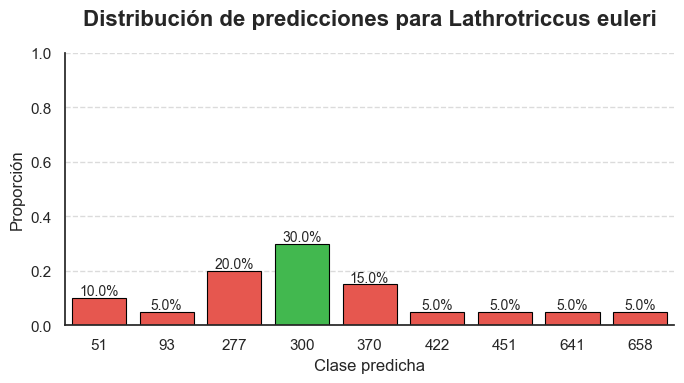

In [40]:
plot_incertidumbres(Lathrotriccus_euleri, 300, "Lathrotriccus euleri")

/Users/camcortes/Documents/birds-sounds/src/incertidumbres.py:378: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


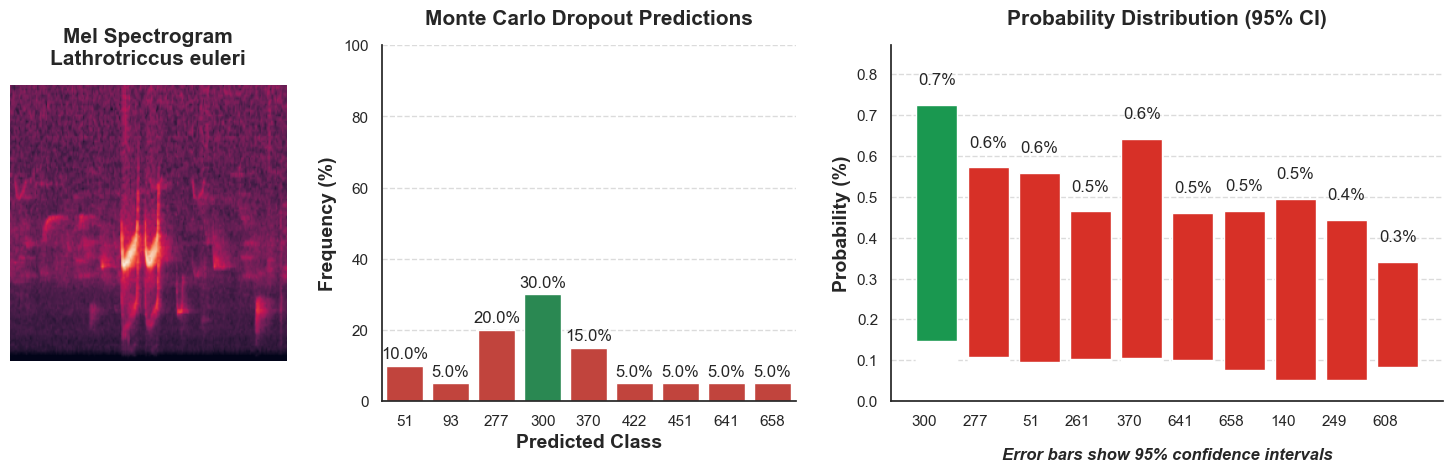

In [41]:
plot_combinado(
    ruta_imagen=sp['image_path'].iloc[20],
    especie_df=Lathrotriccus_euleri,
    label=300,
    titulo_especie="Lathrotriccus euleri",
    predicted_probabilities=resultados["Lathrotriccus euleri"]["predicted_probabilities"],
    etiqueta_real=resultados["Lathrotriccus euleri"]["clase_real"][0]
)

In [42]:
labels_frecuencia = [51, 240, 249, 261, 227, 300, 370, 608, 641, 658]

print("Especies con mayor probabilidad:\n")
for idx, label in enumerate(labels_frecuencia):
    print(f"{idx+1} - {label}: {label_encoder.inverse_transform([label])[0]}")

Especies con mayor probabilidad:

1 - 51: Cacicus cela
2 - 240: Grallaria squamigera
3 - 249: Gymnopithys rufigula
4 - 261: Henicorhina leucosticta
5 - 227: Grallaria alleni
6 - 300: Lathrotriccus euleri
7 - 370: Myiozetetes similis
8 - 608: Thraupis episcopus
9 - 641: Vireo chivi
10 - 658: Xiphorhynchus guttatus
